# Язык Сталина за полвека: корпусные меры

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/ruTS/blob/master/examples/04_stalin_corpus.ipynb)

[`StalinWorks`](https://sergeyshk.github.io/ruTS/datasets/stalinworks/) - полное собрание сочинений в 16 томах, 1243 текста с 1901 по 1952 год, 1.25 млн слов, у каждого текста год и тип (статья, доклад, письмо, приказ). Это единственный набор в библиотеке с датами, и на нём удобно показать корпусные меры [ruTS](https://github.com/SergeyShk/ruTS) как инструменты диахронии: [ключевые слова](https://sergeyshk.github.io/ruTS/corpus/keyness/) относительно частотного словаря и между периодами, [коллокации](https://sergeyshk.github.io/ruTS/corpus/collocations/) одного слова по периодам, [дисперсию](https://sergeyshk.github.io/ruTS/corpus/dispersion/) слов по томам, [конкорданс KWIC](https://sergeyshk.github.io/ruTS/corpus/kwic/) и закон Ципфа по периодам.

Предмет - язык, а не история: что менялось в словаре и сочетаемости от подпольной публицистики до приказов военных лет.

## Установка и данные

В Colab ячейка ставит библиотеку; модель spaCy не нужна. Набор `StalinWorks` (архив 2 МБ) и частотный словарь Ляшевской и Шарова (`FreqDict`, 0.5 МБ) загружаются один раз.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ruts") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ruts"], check=True)

In [2]:
import pandas as pd

from ruts.datasets import FreqDict, StalinWorks

sw = StalinWorks()
sw.download()
freq_dict = FreqDict()
freq_dict.download()

records = sorted(sw.get_records(), key=lambda record: (record["volume"], int(record["file"].name)))
corpus = pd.DataFrame(
    {
        "volume": record["volume"],
        "year": record["year"],
        "type": record["type"],
        "text": record["text"],
    }
    for record in records
)
print(len(corpus), "текстов,", corpus["year"].min(), "-", corpus["year"].max())
corpus["type"].value_counts().head(8).to_frame("текстов").T

1243 текстов, 1901 - 1952


type,Статья,Доклад,Выступление,Письмо,Беседа,Приказ,Телеграмма,Брошюра
текстов,485,367,108,101,70,29,20,17


Четыре периода по содержанию томов: подполье и Дума (1901-1913, тома 1-2), революция и борьба в партии (1917-1927, тома 3-10), коллективизация и индустриализация (1928-1940, тома 11-14), война и послевоенные годы (1941-1952, тома 15-16). Периоды неравны: на второй приходится почти половина слов.

,текстов,слов
period,,
1901-1913,148,137996
1917-1927,657,570359
1928-1940,283,297732
1941-1952,155,108799


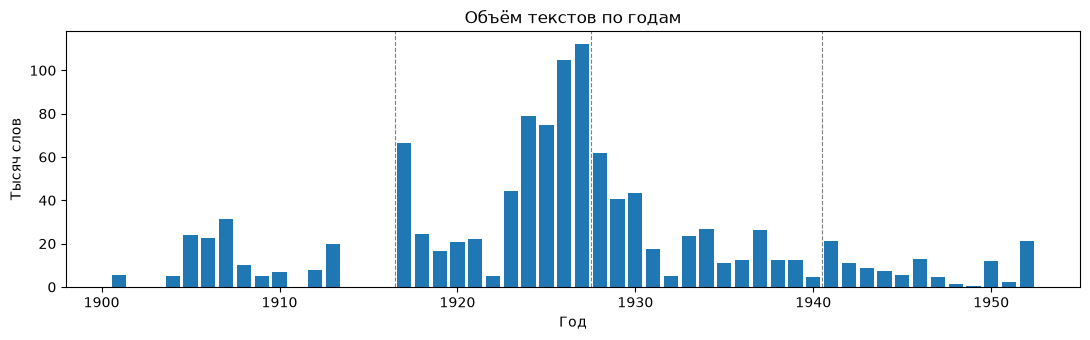

In [3]:
import matplotlib.pyplot as plt

from ruts import WordsExtractor

PERIODS = [(1901, 1913), (1917, 1927), (1928, 1940), (1941, 1952)]


def period_of(year: int) -> str:
    """Название периода по году"""
    for start, end in PERIODS:
        if start <= year <= end:
            return f"{start}-{end}"
    raise ValueError(year)


lemmatizer = WordsExtractor(use_lexemes=True, lowercase=True, filter_nums=True)
corpus["period"] = corpus["year"].map(period_of)
corpus["lemmas"] = [lemmatizer.extract(text) for text in corpus["text"]]
corpus["n_words"] = corpus["lemmas"].map(len)

by_year = corpus.groupby("year")["n_words"].sum() / 1000
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(by_year.index, by_year.to_numpy())
for start, _ in PERIODS[1:]:
    ax.axvline(start - 0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Год")
ax.set_ylabel("Тысяч слов")
ax.set_title("Объём текстов по годам")
fig.tight_layout()
corpus.groupby("period")["n_words"].agg(["size", "sum"]).rename(
    columns={"size": "текстов", "sum": "слов"}
)

## Ключевые слова относительно частотного словаря

`keyness` сравнивает частоты лемм корпуса с частотным словарём современного русского языка (НКРЯ, 92 млн словоупотреблений): для каждого слова G² с p-значением и Log Ratio - во сколько раз (в двоичных логарифмах) слово чаще в корпусе, чем в языке. Верх списка ожидаем: «партия», «пролетариат», «революция», «буржуазия», «диктатура». Но в нём же «должный», «основный», «тем» - это не слова Сталина, а расхождение лемматизаторов. pymorphy3 приводит «должен» к «должный», а у «основной» лемма распадается на две: сама форма «основной» получает лемму «основной», большинство остальных («основных», «основным», «основная») - «основный»; словарь построен на MyStem, где такой леммы почти нет (ipm 0.4), отсюда Log Ratio 10.9. Сравнение с внешним словарём чувствительно к соглашениям лемматизации, и такие слова надо проверять по конкордансу, прежде чем интерпретировать.

In [4]:
from ruts.corpus import keyness

all_lemmas = [lemma for lemmas in corpus["lemmas"] for lemma in lemmas]
keywords = keyness(all_lemmas, freq_dict, min_freq=50, top_n=25)
pd.DataFrame(
    {
        "слово": [keyword.word for keyword in keywords],
        "частота": [keyword.freq_target for keyword in keywords],
        "G²": [round(keyword.g2) for keyword in keywords],
        "Log Ratio": [round(keyword.log_ratio, 1) for keyword in keywords],
    }
).set_index("слово").T

слово,партия,пролетариат,рабочий,должный,революция,крестьянство,тем,буржуазия,наш,ленин,...,капиталистический,диктатура,хозяйство,страна,класс,троцкий,оппозиция,против,основный,капитализм
частота,7417.0,3260.0,5600.0,3027.0,4109.0,1647.0,1841.0,1506.0,8067.0,2322.0,...,1353.0,1286.0,2279.0,4510.0,2561.0,1218.0,1399.0,2811.0,872.0,1236.0
G²,32385.0,24990.0,23825.0,20821.0,19946.0,12214.0,11235.0,11021.0,10566.0,10561.0,...,8848.0,8422.0,8019.0,7897.0,7866.0,7746.0,7653.0,7576.0,7410.0,7092.0
Log Ratio,4.7,8.5,4.6,7.3,5.2,8.0,6.4,7.9,2.1,4.9,...,6.9,6.9,4.0,2.5,3.6,6.6,5.7,3.3,10.9,6.0


## Ключевые слова периодов

Сравнение периода с остальным корпусом свободно от проблемы лемматизации - обе стороны разобраны одним инструментом. Слова каждого периода складываются в его повестку: Дума, стачки, социал-демократия и ликвидаторы до 1917 года; революция, оппозиция, Троцкий, Зиновьев и Гоминдан в 1917-1927; колхозы, совхозы, кулачество, пятилетка и самокритика в 1928-1940; Красная армия, немцы, война, родина и захватчики в 1941-1952.

In [5]:
lemmas_by_period = {
    period: [lemma for lemmas in group["lemmas"] for lemma in lemmas]
    for period, group in corpus.groupby("period")
}
period_keywords = {}
for period, target in lemmas_by_period.items():
    others = [lemmas for other, lemmas in lemmas_by_period.items() if other != period]
    rest = [lemma for lemmas in others for lemma in lemmas]
    period_keywords[period] = keyness(target, rest, min_freq=20, top_n=15)
pd.DataFrame({period: [item.word for item in found] for period, found in period_keywords.items()})

,1901-1913,1917-1927,1928-1940,1941-1952
0,дума,революция,колхоз,красный
1,нефтепромышленник,оппозиция,хозяйство,армия
2,социал-демократия,троцкий,совхоз,немецкий
3,анархист,партия,колхозный,язык
4,рабочий,совет,бухарин,война
5,социал-демократ,зиновьев,хлеб,войско
6,самодержавие,власть,человек,гитлеровский
7,сознание,империализм,кулачество,германия
8,кадет,диктатура,мы,советский
9,маркс,революционный,пятилетка,производство


Два крайних периода лицом к лицу: `keyness_plot` рисует расходящиеся столбцы по G² - слова революции влево, слова войны вправо.

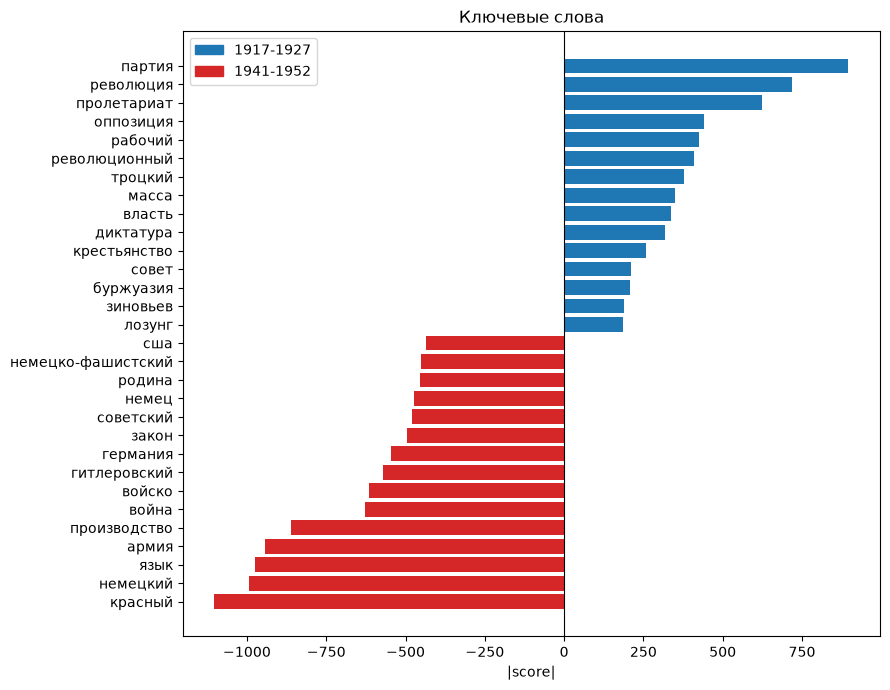

In [6]:
from ruts.visualizers import keyness_plot

early, late = lemmas_by_period["1917-1927"], lemmas_by_period["1941-1952"]
fig, ax = plt.subplots(figsize=(9, 7))
keyness_plot(
    keyness(early, late, min_freq=20, top_n=15),
    keyness(late, early, min_freq=20, top_n=15),
    top_n=15,
    labels=("1917-1927", "1941-1952"),
    ax=ax,
)
fig.tight_layout()

## Коллокации одного слова по периодам

`collocations` с параметром `node` отдаёт сочетаемость одного слова; мера logDice не зависит от размера корпуса, поэтому периоды сравнимы. Стоп-слова (союзы, предлоги, местоимения, частицы по разметке pymorphy3 - `is_stopword`) убраны заранее, окно - два слова. Пары в `collocations` упорядоченные, поэтому оба направления («классовый враг» и «враг классовый») складываются в одну строку с суммой частот и лучшей мерой, а сам узел из списка исключается. У слова «враг» сочетаемость меняется по периодам как по учебнику: «общий враг» и «враг революции» в подполье, «внешний» и «внутренний» враг в 1917-1927, «классовый враг» и «враг народа» в 1928-1940, «разгром», «победа над врагом» и «бить врага» в войну. «Партия» из «социал-демократической» и «рабочей» становится «коммунистической», потом «линией», «съездом» и «политикой», а в 1941-1952 её «приветствуют» и «поздравляют» - это тексты телеграмм братским партиям.

In [7]:
from ruts.corpus import collocations
from ruts.style_stats import is_stopword

content_by_period = {
    period: [lemma for lemma in lemmas if not is_stopword(lemma)]
    for period, lemmas in lemmas_by_period.items()
}


def collocates(node: str, top_n: int = 8) -> pd.DataFrame:
    """Сильнейшие коллокаты слова по периодам: оба направления пары в одной строке"""
    table = {}
    for period, words in content_by_period.items():
        merged: dict[str, tuple[int, float]] = {}
        for item in collocations(words, window=2, min_freq=4, node=node):
            other = item.left if item.right == node else item.right
            if other == node:
                continue
            freq, score = merged.get(other, (0, float("-inf")))
            merged[other] = (freq + item.freq_pair, max(score, item.score))
        best = sorted(merged.items(), key=lambda pair: (-pair[1][1], pair[0]))[:top_n]
        table[period] = [f"{word} ({freq})" for word, (freq, _) in best]
    return pd.DataFrame.from_dict(table, orient="index").T


collocates("враг")

,1901-1913,1917-1927,1928-1940,1941-1952
0,внутренний (4),заклятый (12),классовый (43),победа (17)
1,общий (8),внешний (25),внешний (18),разгром (12)
2,настоящий (4),страх (7),заклятый (9),бить (10)
3,народ (6),радость (6),народ (15),общий (11)
4,друг (4),опасный (7),внутренний (15),удар (8)
5,революция (7),друг (13),класс (28),уже (8)
6,являться (5),внутренний (15),рабочий (25),отбросить (6)
7,борьба (7),общий (12),слабость (5),борьба (8)


In [8]:
collocates("партия")

,1901-1913,1917-1927,1928-1940,1941-1952
0,социал-демократический (64),коммунистический (155),член (132),коммунистический (44)
1,член (40),член (150),линия (95),большевистский (13)
2,рабочий (77),быть (338),съезд (81),поздравлять (13)
3,должный (40),мочь (215),коммунистический (47),приветствовать (13)
4,быть (75),задача (134),политика (68),правительство (15)
5,единый (25),съезд (127),мочь (65),братский (7)
6,съезд (29),рабочий (247),задача (44),демократический (7)
7,программа (21),есть (148),цк (55),член (7)


## Дисперсия слов по томам

Частота говорит, сколько раз слово встретилось, дисперсия - насколько равномерно. `dispersion` с размерами частей по томам считает DP Гриса: 0 - слово распределено ровно, 1 - собрано в одном месте. Среди частых слов (от 200 вхождений) самые неровные - имена и реалии одного периода: Гоминдан, Керенский, кадеты и Дума, совхозы, Зиновьев; самые ровные - служебные слова и «быть».

In [9]:
from ruts.corpus import dispersion

volume_sizes = corpus.groupby("volume")["n_words"].sum().sort_index().tolist()
spread = pd.DataFrame(
    {"слово": item.word, "частота": item.freq, "DP": item.dp}
    for item in dispersion(all_lemmas, parts=volume_sizes, min_freq=200)
).set_index("слово")
pd.concat(
    [
        spread.sort_values("DP", ascending=False).head(10),
        spread.sort_values("DP").head(5),
    ]
).round(2)

,частота,DP
слово,,
гоминдан,273,0.82
автономия,297,0.76
керенский,211,0.75
окраина,227,0.74
кадет,483,0.74
дума,387,0.73
совхоз,276,0.71
зиновьев,549,0.70
оппозиционный,205,0.70


`dispersion_plot` показывает те же слова как штрихи вдоль корпуса, выстроенного по времени: где слово живёт, а где его нет. Пунктир - границы периодов.

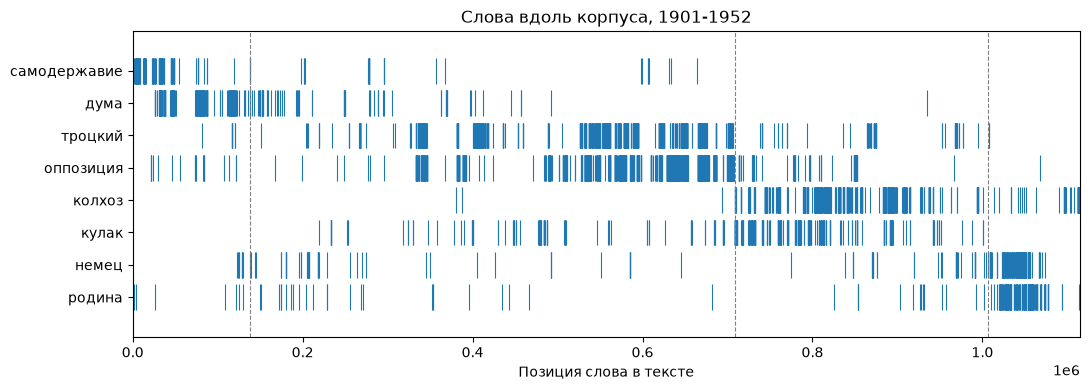

In [10]:
from ruts.visualizers import dispersion_plot

TARGETS = ["самодержавие", "дума", "троцкий", "оппозиция", "колхоз", "кулак", "немец", "родина"]
fig, ax = plt.subplots(figsize=(11, 4))
dispersion_plot(all_lemmas, TARGETS, ax=ax)
boundary = 0
for lemmas in list(lemmas_by_period.values())[:-1]:
    boundary += len(lemmas)
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Слова вдоль корпуса, 1901-1952")
fig.tight_layout()

## Конкорданс

Ключевые слова и коллокации показывают, что и с чем сочетается, конкорданс - как именно. `kwic` ищет словосочетание по леммам, поэтому «враг народа» находит и «врагов народа», и «врагами народа». Первые пять из 15 вхождений в текстах 1928-1940 годов.

In [11]:
from ruts.corpus import kwic, print_kwic

text_1930s = "\n".join(corpus.loc[corpus["period"] == "1928-1940", "text"])
concordance = kwic(text_1930s, "враг народа", window=6, by_lemma=True)
print(len(concordance), "вхождений")
print_kwic(concordance[:5], width=45)

15 вхождений
     господам Милюковым, плетется в хвосте за  врагами народа  . е) О темпе развития индустрии и
перед рабочим классом и крестьянством. Только  враги народа    и контрреволюционеры могут ставить вопрос о
      что не сумели разглядеть настоящее лицо  врагов народа   , не сумели распознать волков в овечьей
рьезным предупреждением, говорящим о том, что  враги народа    будут двурушничать и, двурушничая, будут маск
симальной бдительности, к умению распознавать  врагов народа   , как бы хорошо они ни были


## Закон Ципфа по периодам

Подгонка закона Ципфа-Мандельброта $f(r) = C / (r + q)^s$ к частотам словоформ каждого периода. Показатель $s$ у всех периодов 1.0-1.2, как у обычного текста, а доля гапаксов (слов, встретившихся один раз) - половина словаря. Сравнивать периоды по $s$ и $q$ напрямую нельзя - объёмы различаются в пять раз, а подгонка от объёма зависит; от объёма зависит и доля гапаксов, что видно по таблице: 0.47 у самого большого периода против 0.53 у двух самых маленьких. Не зависит от длины только MTLD по окнам в 1000 слов, и по нему период 1928-1940 ниже всех (146 против 204 в подполье и в войну) - доклады о хозяйстве и колхозах повторяют одни и те же слова чаще, чем полемика и приказы.

,слов,словоформ,гапаксов,s,q,MTLD по окнам
период,,,,,,
1901-1913,137996,21018,0.53,1.03,9.37,204.03
1917-1927,570359,45999,0.47,1.23,69.07,174.47
1928-1940,297732,31572,0.50,1.15,31.54,145.98
1941-1952,108799,18449,0.53,1.01,10.06,203.63


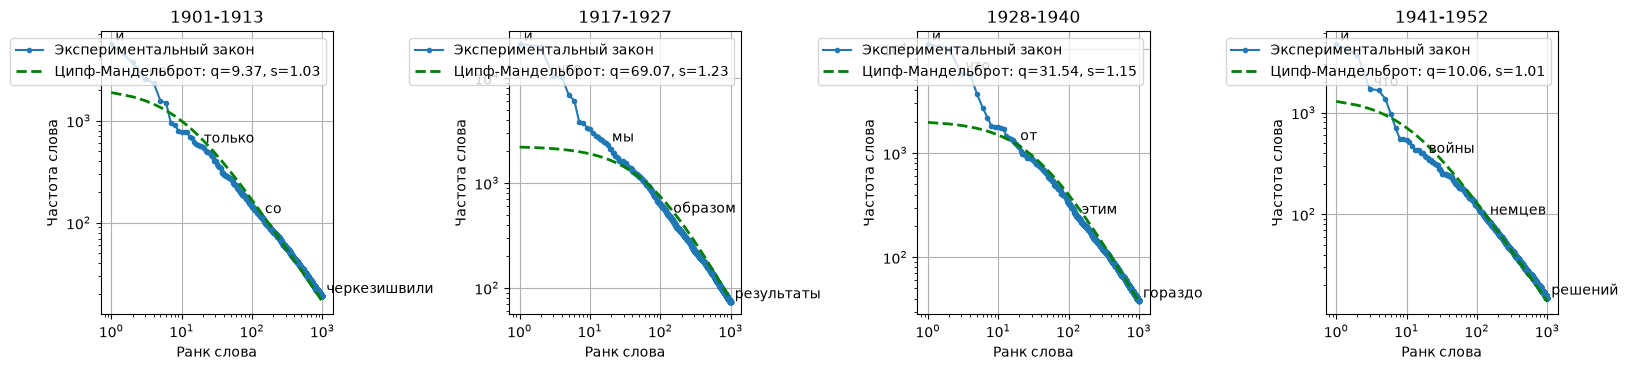

In [12]:
from collections import Counter

from ruts import DiversityStats
from ruts.diversity_stats import fit_zipf_mandelbrot
from ruts.visualizers import zipf

extractor = WordsExtractor(lowercase=True, filter_nums=True)
forms_by_period = {
    period: [form for text in group["text"] for form in extractor.extract(text)]
    for period, group in corpus.groupby("period")
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
rows = []
for ax, (period, forms) in zip(axes, forms_by_period.items(), strict=True):
    counter = Counter(forms)
    fit = fit_zipf_mandelbrot(counter)
    mtld_windowed = DiversityStats(" ".join(forms)).windowed("mtld", window_len=1000).mean
    zipf(counter, num_words=1000, num_labels=5, show_fit=True, ax=ax)
    ax.set_title(period)
    rows.append(
        {
            "период": period,
            "слов": len(forms),
            "словоформ": len(counter),
            "гапаксов": sum(1 for count in counter.values() if count == 1) / len(counter),
            "s": fit.s,
            "q": fit.q,
            "MTLD по окнам": mtld_windowed,
        }
    )
fig.tight_layout()
pd.DataFrame(rows).set_index("период").round(2)

## Итоги

*   Ключевые слова относительно частотного словаря показывают тему корпуса (партия, пролетариат, революция, буржуазия, диктатура), но приносят и артефакты лемматизации («должный», распавшийся на две леммы «основной»): сравнение с внешним словарём требует одинаковых лемм с обеих сторон, сравнение периодов внутри корпуса от этого свободно.
*   Ключевые слова четырёх периодов - четыре повестки: Дума и социал-демократия, революция и оппозиция, колхозы и пятилетка, война и Красная армия.
*   Сочетаемость одного слова по периодам - самый наглядный инструмент диахронии: «враг» от «общего» через «внешнего и внутреннего» к «классовому» и «врагу народа», а в войну - к «разгрому» и «победе»; «партия» от «социал-демократической» к «коммунистической», «линии» и «съезду».
*   Дисперсия отделяет слова-события от слов-фона: имена и реалии одного периода (Гоминдан, Керенский, кадеты, совхозы) собраны в одном месте корпуса, служебные слова распределены ровно; `dispersion_plot` показывает это как ленту времени.
*   Конкорданс подтверждает сочетаемость на живых примерах, а поиск по леммам находит все формы словосочетания.
*   Закон Ципфа по периодам одинаков ($s$ = 1.0-1.2); параметры подгонки и доля гапаксов зависят от объёма, различия в разнообразии видны только по MTLD в окнах одной длины - ниже всего в текстах 1928-1940 годов.